# Spectrogram & Time-Frequency Analysis Utility

Spectrograms are essential for analyzing signals whose frequency content changes over time, like sonar pings, chirps, and echoes.

---

## 1. Theory

- **Spectrogram:** Plots how frequency components in a signal evolve with time. x = time, y = frequency, color = amplitude/power.
- **In sonar:** Used to visualize pings, multipath, Doppler, and target returns.
- **Core DSP tool** for any non-stationary signal.

---


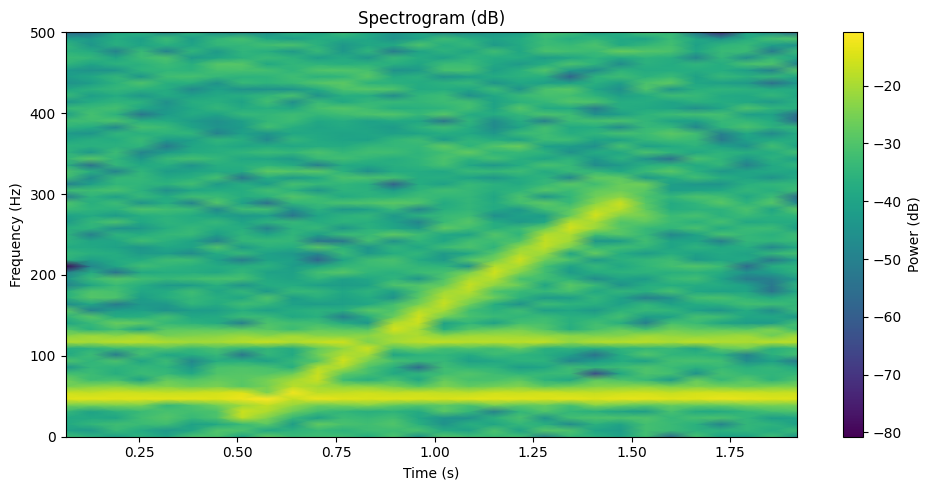

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, spectrogram

fs = 1000
t = np.linspace(0, 2, 2*fs, endpoint=False)
# Signal: low freq + high freq + chirp
sig = np.sin(2*np.pi*50*t) + 0.6*np.sin(2*np.pi*120*t)
sig[500:1500] += chirp(t[:1000], f0=20, f1=300, t1=1, method='linear')
sig += 0.4*np.random.randn(len(t))

# Spectrogram
f, tt, Sxx = spectrogram(sig, fs, nperseg=128, noverlap=64)
plt.figure(figsize=(10,5))
plt.pcolormesh(tt, f, 10*np.log10(Sxx+1e-10), shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram (dB)')
plt.colorbar(label='Power (dB)')
plt.tight_layout()
plt.show()


## Notes
- Adjust window size (`nperseg`) and overlap for better time or frequency resolution.
- Spectrograms are used for feature extraction, event detection, and visualization in all signal processing domains.

---
**Copy/adapt this for your real data or for interview demos. Works with sonar, audio, seismic, etc.**
